In [37]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [38]:
from fem import (
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_gmsh_mesh,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [39]:
globalParameters['nDoF'] = 3
globalParameters['nDIM'] = 3

In [40]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'example'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [41]:
# # Material
# Steel=Material( name='Steel',
#                 E=2000,
#                 nu=0.30,
#                 rho=1.25*tf/m**3*0)

# # Sections
# F1=Membrane(    name='F1',
#                 thickness=15,
#                 material=Steel)

# # Dictionaries
# section_dictionary={274:F1,
#                         }

# restrain_dictionary={275:['r', 'r' , 'r'] , 
#                      277: ['f' , 'f' , 'r']}

load_dictionary = {
                257:   {'value': 4, 'direction': '-y'},     
}

In [42]:
# Read mesh
mesh = GMSHtools(output_file)

system_nDof = mesh.system_nDof
node_map = mesh.node_map


  MESH SUMMARY

  === NODES ===  (1145 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         2.0000        -0.2500         0.0000
       2         2.5000        -0.2500         0.0000
       3         0.2500        -0.2500         2.4875
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (2 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      53      2   'support'
      54      3   'solid'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (2 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      53      2        2          3          104   'support'
      54      3        4          4         3144   

In [43]:
# remove floating nodes
connected_nodes = set()
for group in mesh.elements.values():
    for conn in group['connectivity']:
        connected_nodes.update(conn)

floating = set(mesh.nodes.keys()) - connected_nodes
for tag in floating:
    del mesh.nodes[tag]
print(f"Removed {len(floating)} floating nodes: {floating}")

# recalculate node_map and system_nDof
from fem.utils.functions import plan
mesh.node_map, mesh.system_nDof = plan(mesh)

node_map    = mesh.node_map
system_nDof = mesh.system_nDof

Removed 0 floating nodes: set()


In [44]:
# # Load vector
# F_nodal = build_load_vector(mesh, 
#                             load_dictionary)

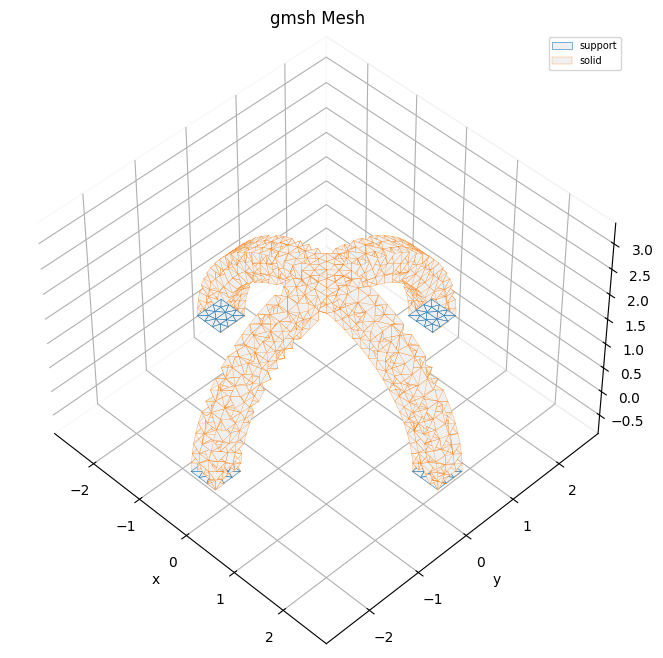

In [45]:
# %matplotlib widget

plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
               view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

## Opensees

In [46]:
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 3, '-ndf', 3)

In [47]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y , z)

In [48]:
# Boundary conditions
fixed_nodes = set()
for tag in mesh.physical_groups['support'].nodes:
    if tag not in fixed_nodes:
        fixed_nodes.add(tag)
        # ops.fix(tag, 1, 1, 1, 1, 1, 1)
        ops.fix(tag, 1, 1, 1)

In [49]:
# Material
E = 210e9      
nu = 0.33
rho=7300
g=9.81
ops.nDMaterial('ElasticIsotropic', 1, E, nu, rho)


In [50]:
group = mesh.physical_groups['solid'].elements
for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
    n1, n2, n3, n4 = conn
    ops.element('FourNodeTetrahedron', elem_tag, n1, n2, n3, n4, 1)

In [51]:
# opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [52]:
# calcular volumen de cada tetrahedro y repartir peso a nodos
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

nodal_weight = {}
for conn in group['connectivity']:
    n1, n2, n3, n4 = conn
    pts = [np.array(mesh.nodes[n][:3]) for n in [n1, n2, n3, n4]]
    vol = abs(np.dot(pts[1]-pts[0], np.cross(pts[2]-pts[0], pts[3]-pts[0]))) / 6.0
    weight = rho * g * vol / 4.0
    for tag in [n1, n2, n3, n4]:
        nodal_weight[tag] = nodal_weight.get(tag, 0.0) + weight

for tag, w in nodal_weight.items():
    ops.load(tag, 0., 0., -w)

In [53]:
NstepGravity = 10
DGravity = 1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity)
ops.test("NormUnbalance", 1.0e-6, 100, 0)
ops.algorithm("Newton")
ops.analysis("Static")

node_tags = np.array(list(mesh.nodes.keys()))
n_nodes   = len(mesh.nodes)

gmsh.initialize()
gmsh.open(output_file)

view_disp = gmsh.view.add("Displacements")

for step in range(NstepGravity):
    ops.analyze(1)

    u_3d = np.zeros((n_nodes, 3))
    for i, tag in enumerate(mesh.nodes.keys()):
        u_3d[i, 0] = ops.nodeDisp(tag, 1)
        u_3d[i, 1] = ops.nodeDisp(tag, 2)
        u_3d[i, 2] = ops.nodeDisp(tag, 3)

    gmsh.view.addHomogeneousModelData(
        tag=view_disp, step=step, time=float(step),
        modelName=gmsh.model.getCurrent(),
        dataType="NodeData", numComponents=-1,
        tags=node_tags, data=u_3d.reshape(-1))

gmsh.view.option.setNumber(view_disp, "VectorType",          5)
gmsh.view.option.setNumber(view_disp, "DisplacementFactor",  5e4)

gmsh.fltk.run()
gmsh.finalize()